In [3]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

from pathlib import Path

In [56]:
# =========================================================
#  LOAD DATASETS
# =========================================================

orders = pd.read_csv(
    "D:/E-COMMERCE CUSTOMER INTELLIGENCE & BUSINESS ANALYTICS/Dataset/olist_orders_dataset.csv"
)

order_items = pd.read_csv(
    "D:/E-COMMERCE CUSTOMER INTELLIGENCE & BUSINESS ANALYTICS/Dataset/olist_order_items_dataset.csv"
)

products = pd.read_csv(
    "D:/E-COMMERCE CUSTOMER INTELLIGENCE & BUSINESS ANALYTICS/Dataset/olist_products_dataset.csv"
)

customers = pd.read_csv(
    "D:/E-COMMERCE CUSTOMER INTELLIGENCE & BUSINESS ANALYTICS/Dataset/olist_customers_dataset.csv"
)

sellers = pd.read_csv(
    "D:/E-COMMERCE CUSTOMER INTELLIGENCE & BUSINESS ANALYTICS/Dataset/olist_sellers_dataset.csv"
)

reviews = pd.read_csv(
    "D:/E-COMMERCE CUSTOMER INTELLIGENCE & BUSINESS ANALYTICS/Dataset/olist_order_reviews_dataset.csv"
)

payments = pd.read_csv(
    "D:/E-COMMERCE CUSTOMER INTELLIGENCE & BUSINESS ANALYTICS/Dataset/olist_order_payments_dataset.csv"
)

category_translation = pd.read_csv(
    "D:/E-COMMERCE CUSTOMER INTELLIGENCE & BUSINESS ANALYTICS/Dataset/product_category_name_translation.csv"
)

## Dataset Overview

In [9]:
datasets = {
    "orders": orders,
    "order_items": order_items,
    "products": products,
    "customers": customers,
    "sellers": sellers,
    "reviews": reviews,
    "payments": payments
}

for name, df in datasets.items():
    print(f"{name}: {df.shape}")

orders: (99441, 8)
order_items: (112650, 7)
products: (32951, 9)
customers: (99441, 5)
sellers: (3095, 4)
reviews: (99224, 7)
payments: (103886, 5)


In [10]:
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [11]:
orders.info()

<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   order_id                       99441 non-null  str  
 1   customer_id                    99441 non-null  str  
 2   order_status                   99441 non-null  str  
 3   order_purchase_timestamp       99441 non-null  str  
 4   order_approved_at              99281 non-null  str  
 5   order_delivered_carrier_date   97658 non-null  str  
 6   order_delivered_customer_date  96476 non-null  str  
 7   order_estimated_delivery_date  99441 non-null  str  
dtypes: str(8)
memory usage: 6.1 MB


### missing values

In [ ]:

missing_values = (
    orders.isnull()
    .sum()
    .sort_values(ascending=False)
)

missing_values[missing_values > 0]

order_delivered_customer_date    2965
order_delivered_carrier_date     1783
order_approved_at                 160
dtype: int64

In [ ]:
# for all the datasets, check for missing values

for name, df in datasets.items():

    missing = df.isnull().sum()

    missing = missing[missing > 0]

    print(f"\n{name}")
    print(missing)


orders
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

order_items
Series([], dtype: int64)

products
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64

customers
Series([], dtype: int64)

sellers
Series([], dtype: int64)

reviews
review_comment_title      87656
review_comment_message    58247
dtype: int64

payments
Series([], dtype: int64)


Data types

In [20]:
for name, df in datasets.items():
    print("\n" + "=" * 60)
    print(name.upper())
    print("=" * 60)
    print(df.dtypes)


ORDERS
order_id                                    str
customer_id                                 str
order_status                                str
order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

ORDER_ITEMS
order_id                   str
order_item_id            int64
product_id                 str
seller_id                  str
shipping_limit_date        str
price                  float64
freight_value          float64
dtype: object

PRODUCTS
product_id                        str
product_category_name             str
product_name_lenght           float64
product_description_lenght    float64
product_photos_qty            float64
product_weight_g              float64
product_length_cm             float64
product_height_cm             float64
product_width_cm              float6

In [21]:
# =========================================================
# 7. DATE CONVERSION
# =========================================================

date_columns = [
    "order_purchase_timestamp",
    "order_approved_at",
    "order_delivered_carrier_date",
    "order_delivered_customer_date",
    "order_estimated_delivery_date"
]

for col in date_columns:
    orders[col] = pd.to_datetime(
        orders[col],
        errors="coerce"
    )

print("Date columns converted successfully.")

orders[date_columns].dtypes

Date columns converted successfully.


order_purchase_timestamp         datetime64[us]
order_approved_at                datetime64[us]
order_delivered_carrier_date     datetime64[us]
order_delivered_customer_date    datetime64[us]
order_estimated_delivery_date    datetime64[us]
dtype: object

##  Data Preparation

The order item table contains product-level transactions, while the orders
table contains order-level information.

For business analysis, we aggregate order items to order level and create
a single analytical dataset.

In [22]:
# =========================================================
# CREATE ORDER-LEVEL ANALYTICAL DATASET
# =========================================================

# Aggregate order items to order level
order_sales = (
    order_items
    .groupby("order_id", as_index=False)
    .agg(
        product_revenue=("price", "sum"),
        freight_value=("freight_value", "sum"),
        items_count=("order_item_id", "count")
    )
)

# Total order value = product revenue + freight
order_sales["total_order_value"] = (
    order_sales["product_revenue"]
    + order_sales["freight_value"]
)

# Merge order information
order_data = orders.merge(
    order_sales,
    on="order_id",
    how="left"
)

# Add customer information
order_data = order_data.merge(
    customers[
        [
            "customer_id",
            "customer_unique_id",
            "customer_state",
            "customer_city"
        ]
    ],
    on="customer_id",
    how="left"
)

print("Order-level dataset created.")
print("Shape:", order_data.shape)

order_data.head()

Order-level dataset created.
Shape: (99441, 15)


,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,product_revenue,freight_value,items_count,total_order_value,customer_unique_id,customer_state,customer_city
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18,29.99,8.72,1.0,38.71,7c396fd4830fd04220f754e42b4e5bff,SP,sao paulo
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13,118.70,22.76,1.0,141.46,af07308b275d755c9edb36a90c618231,BA,barreiras
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04,159.90,19.22,1.0,179.12,3a653a41f6f9fc3d2a113cf8398680e8,GO,vianopolis
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15,45.00,27.20,1.0,72.20,7c142cf63193a1473d2e66489a9ae977,RN,sao goncalo do amarante
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26,19.90,8.72,1.0,28.62,72632f0f9dd73dfee390c9b22eb56dd6,SP,santo andre


In [23]:
# =========================================================
# VALIDATE ANALYTICAL DATASET
# =========================================================

print("Duplicate order IDs:", order_data["order_id"].duplicated().sum())

print("\nMissing values in key analytical columns:")
print(
    order_data[
        [
            "product_revenue",
            "freight_value",
            "items_count",
            "total_order_value"
        ]
    ].isnull().sum()
)

print("\nSummary statistics:")
print(
    order_data[
        [
            "product_revenue",
            "freight_value",
            "items_count",
            "total_order_value"
        ]
    ].describe()
)

Duplicate order IDs: 0

Missing values in key analytical columns:
product_revenue      775
freight_value        775
items_count          775
total_order_value    775
dtype: int64

Summary statistics:
       product_revenue  freight_value   items_count  total_order_value
count     98666.000000   98666.000000  98666.000000       98666.000000
mean        137.754076      22.823562      1.141731         160.577638
std         210.645145      21.650909      0.538452         220.466087
min           0.850000       0.000000      1.000000           9.590000
25%          45.900000      13.850000      1.000000          61.980000
50%          86.900000      17.170000      1.000000         105.290000
75%         149.900000      24.040000      1.000000         176.870000
max       13440.000000    1794.960000     21.000000       13664.080000


## 10. Sales & Revenue Analysis

This section analyzes:

- Monthly revenue
- Monthly orders
- Average Order Value (AOV)
- Month-over-Month revenue growth

In [ ]:
# =========================================================
# FILTER DELIVERED ORDERS
# =========================================================

delivered_orders = order_data[
    order_data["order_status"] == "delivered"
].copy()

print("Delivered orders:", len(delivered_orders))

Delivered orders: 96478


In [ ]:
# =========================================================
# MONTHLY SALES ANALYSIS
# =========================================================

# Create monthly period
delivered_orders["order_month"] = (
    delivered_orders["order_purchase_timestamp"]
    .dt.to_period("M")
)

# Monthly revenue and order count
monthly_sales = (
    delivered_orders
    .groupby("order_month")
    .agg(
        revenue=("product_revenue", "sum"),
        orders=("order_id", "nunique")
    )
    .reset_index()
)

# Average Order Value
monthly_sales["aov"] = (
    monthly_sales["revenue"]
    / monthly_sales["orders"]
)

monthly_sales

,order_month,revenue,orders,aov
0,2016-09,134.97,1,134.970000
1,2016-10,40325.11,265,152.170226
2,2016-12,10.90,1,10.900000
3,2017-01,111798.36,750,149.064480
4,2017-02,234223.40,1653,141.695947
5,2017-03,359198.85,2546,141.083602
6,2017-04,340669.68,2303,147.924307
7,2017-05,489338.25,3546,137.997250
8,2017-06,421923.37,3135,134.584807
9,2017-07,481604.52,3872,124.381333


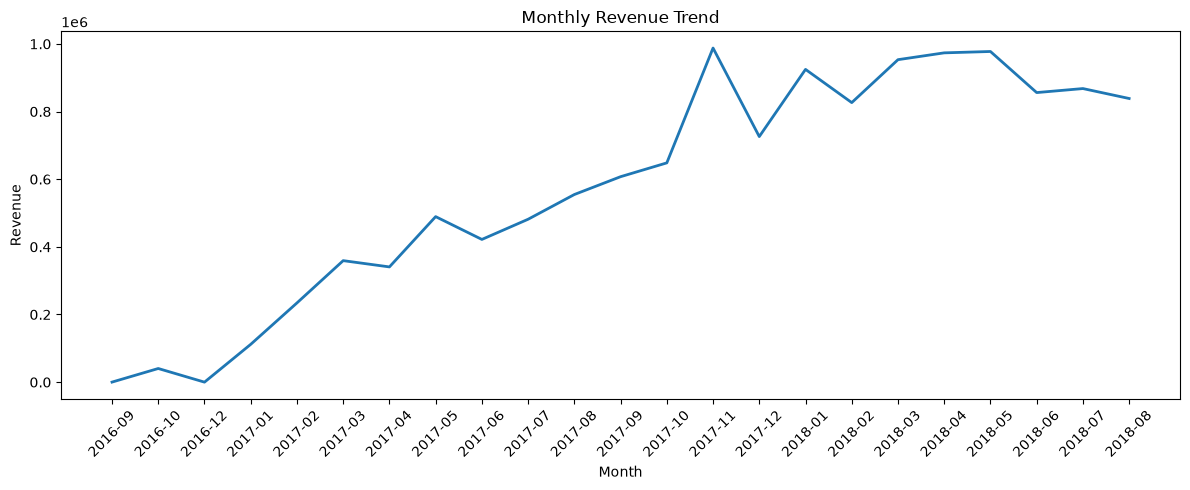

In [26]:
# =========================================================
# 12. MONTHLY REVENUE TREND
# =========================================================

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["order_month"].astype(str),
    monthly_sales["revenue"],
    linewidth=2
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

In [27]:
# =========================================================
# 13. MONTH-OVER-MONTH REVENUE GROWTH
# =========================================================

monthly_sales["mom_growth_pct"] = (
    monthly_sales["revenue"]
    .pct_change()
    * 100
)

monthly_sales[
    [
        "order_month",
        "revenue",
        "orders",
        "aov",
        "mom_growth_pct"
    ]
]

,order_month,revenue,orders,aov,mom_growth_pct
0,2016-09,134.97,1,134.970000,NaN
1,2016-10,40325.11,265,152.170226,2.977709e+04
2,2016-12,10.90,1,10.900000,-9.997297e+01
3,2017-01,111798.36,750,149.064480,1.025573e+06
4,2017-02,234223.40,1653,141.695947,1.095052e+02
5,2017-03,359198.85,2546,141.083602,5.335737e+01
6,2017-04,340669.68,2303,147.924307,-5.158471e+00
7,2017-05,489338.25,3546,137.997250,4.364009e+01
8,2017-06,421923.37,3135,134.584807,-1.377674e+01
9,2017-07,481604.52,3872,124.381333,1.414502e+01


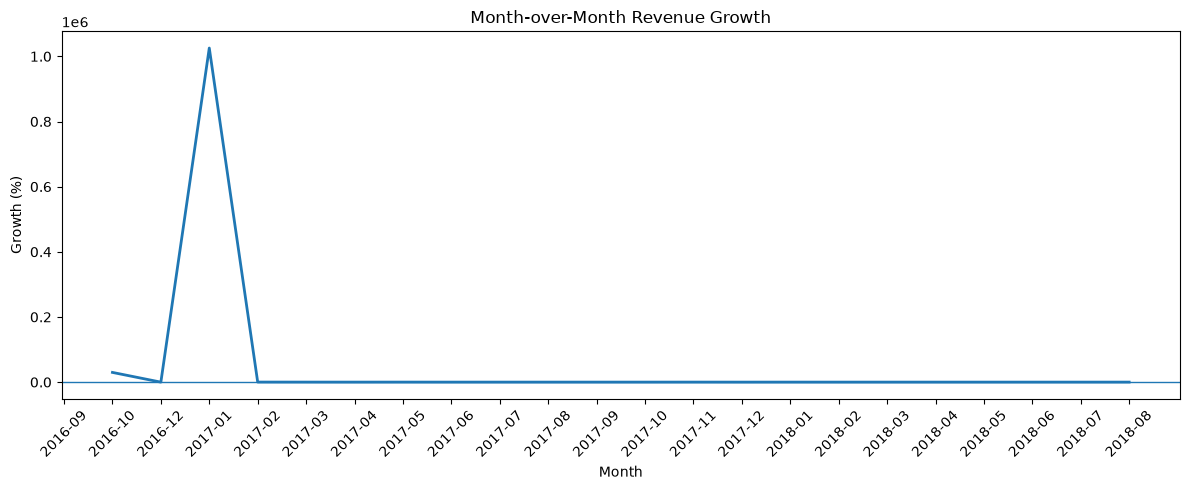

In [28]:
# =========================================================
# 14. MOM REVENUE GROWTH CHART
# =========================================================

plt.figure(figsize=(12, 5))

plt.plot(
    monthly_sales["order_month"].astype(str),
    monthly_sales["mom_growth_pct"],
    linewidth=2
)

plt.axhline(
    0,
    linewidth=1
)

plt.title("Month-over-Month Revenue Growth")
plt.xlabel("Month")
plt.ylabel("Growth (%)")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 15. Product & Category Analysis

This section identifies the highest-performing product categories based on
revenue and sales volume.

In [ ]:
# =========================================================
# CATEGORY PERFORMANCE
# =========================================================

category_sales = (
    order_items
    .merge(
        products[
            [
                "product_id",
                "product_category_name"
            ]
        ],
        on="product_id",
        how="left"
    )
    .merge(
        orders[
            [
                "order_id",
                "order_status"
            ]
        ],
        on="order_id",
        how="left"
    )
)

# Keep delivered orders
category_sales = category_sales[
    category_sales["order_status"] == "delivered"
]

# Add English category names
category_sales = category_sales.merge(
    category_translation,
    on="product_category_name",
    how="left"
)

category_summary = (
    category_sales
    .groupby(
        "product_category_name_english",
        dropna=False
    )
    .agg(
        revenue=("price", "sum"),
        items_sold=("order_item_id", "count"),
        orders=("order_id", "nunique")
    )
    .reset_index()
    .sort_values(
        "revenue",
        ascending=False
    )
)

category_summary.head(10)

,product_category_name_english,revenue,items_sold,orders
43,health_beauty,1233131.72,9465,8647
70,watches_gifts,1166176.98,5859,5495
7,bed_bath_table,1023434.76,10953,9272
65,sports_leisure,954852.55,8431,7530
15,computers_accessories,888724.61,7644,6530
39,furniture_decor,711927.69,8160,6307
49,housewares,615628.69,6795,5743
20,cool_stuff,610204.10,3718,3559
5,auto,578966.65,4140,3810
69,toys,471286.48,4030,3804


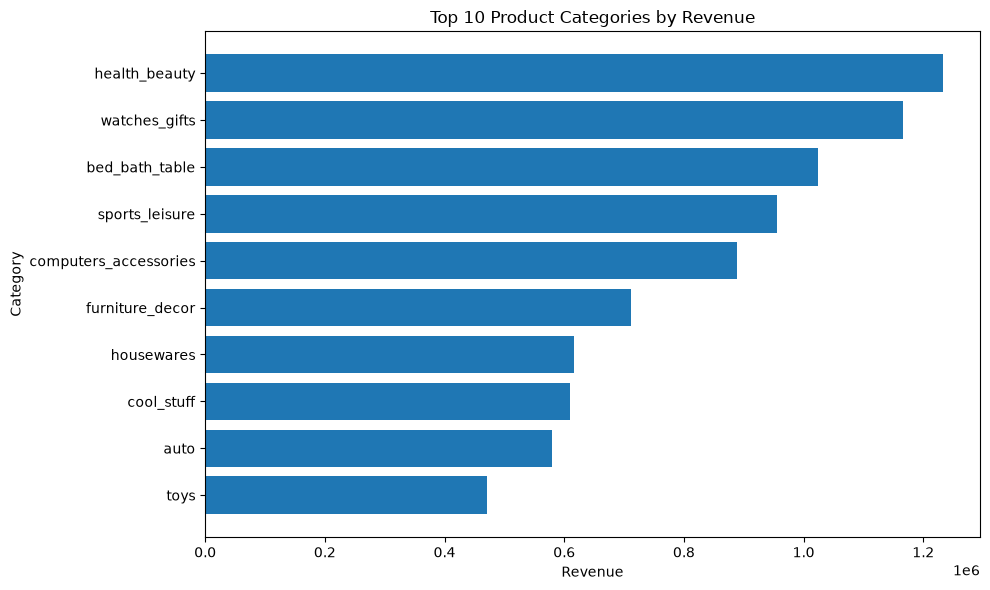

In [ ]:
# =========================================================
# TOP 10 CATEGORIES BY REVENUE
# =========================================================

top_categories = category_summary.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_categories[
        "product_category_name_english"
    ].astype(str)[::-1],
    top_categories["revenue"][::-1]
)

plt.title("Top 10 Product Categories by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Category")

plt.tight_layout()
plt.show()

## 17. Customer Analysis & Retention

This section analyzes:

- One-time vs repeat customers
- Repeat customer rate
- Customer revenue
- First purchase month

In [32]:
# =========================================================
# CUSTOMER ORDER SUMMARY
# =========================================================

customer_orders = (
    delivered_orders
    .groupby("customer_unique_id")
    .agg(
        order_count=("order_id", "nunique"),
        revenue=("product_revenue", "sum")
    )
    .reset_index()
)

# Classify customers
customer_orders["customer_type"] = np.where(
    customer_orders["order_count"] > 1,
    "Repeat Customer",
    "One-Time Customer"
)

customer_orders.head()

,customer_unique_id,order_count,revenue,customer_type
0,0000366f3b9a7992bf8c76cfdf3221e2,1,129.90,One-Time Customer
1,0000b849f77a49e4a4ce2b2a4ca5be3f,1,18.90,One-Time Customer
2,0000f46a3911fa3c0805444483337064,1,69.00,One-Time Customer
3,0000f6ccb0745a6a4b88665a16c9f078,1,25.99,One-Time Customer
4,0004aac84e0df4da2b147fca70cf8255,1,180.00,One-Time Customer


In [33]:
# =========================================================
# ONE-TIME VS REPEAT CUSTOMERS
# =========================================================

retention_summary = (
    customer_orders["customer_type"]
    .value_counts()
)

print(retention_summary)

repeat_rate = (
    customer_orders["order_count"].gt(1).mean()
    * 100
)

print(f"\nRepeat Customer Rate: {repeat_rate:.2f}%")

customer_type
One-Time Customer    90557
Repeat Customer       2801
Name: count, dtype: int64

Repeat Customer Rate: 3.00%


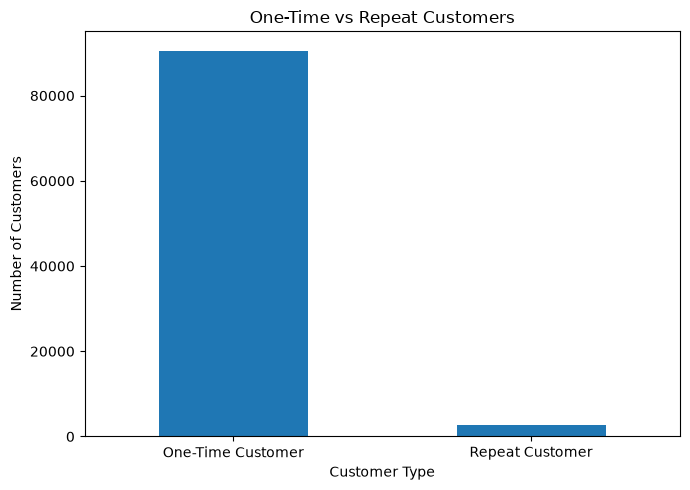

In [34]:
# =========================================================
# CUSTOMER RETENTION CHART
# =========================================================

plt.figure(figsize=(7, 5))

retention_summary.plot(
    kind="bar"
)

plt.title("One-Time vs Repeat Customers")
plt.xlabel("Customer Type")
plt.ylabel("Number of Customers")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

In [35]:
# =========================================================
# FIRST PURCHASE MONTH FOR EACH CUSTOMER
# =========================================================

first_purchase = (
    delivered_orders
    .groupby("customer_unique_id")
    ["order_purchase_timestamp"]
    .min()
    .reset_index()
)

first_purchase.columns = [
    "customer_unique_id",
    "first_purchase_date"
]

first_purchase["first_purchase_month"] = (
    first_purchase["first_purchase_date"]
    .dt.to_period("M")
)

first_purchase.head()

,customer_unique_id,first_purchase_date,first_purchase_month
0,0000366f3b9a7992bf8c76cfdf3221e2,2018-05-10 10:56:27,2018-05
1,0000b849f77a49e4a4ce2b2a4ca5be3f,2018-05-07 11:11:27,2018-05
2,0000f46a3911fa3c0805444483337064,2017-03-10 21:05:03,2017-03
3,0000f6ccb0745a6a4b88665a16c9f078,2017-10-12 20:29:41,2017-10
4,0004aac84e0df4da2b147fca70cf8255,2017-11-14 19:45:42,2017-11


In [ ]:
# =========================================================
# CUSTOMER ACQUISITION TREND
# =========================================================

new_customers_monthly = (
    first_purchase
    .groupby("first_purchase_month")
    .size()
    .reset_index(
        name="new_customers"
    )
)

new_customers_monthly

,first_purchase_month,new_customers
0,2016-09,1
1,2016-10,262
2,2016-12,1
3,2017-01,717
4,2017-02,1628
5,2017-03,2503
6,2017-04,2256
7,2017-05,3451
8,2017-06,3037
9,2017-07,3752


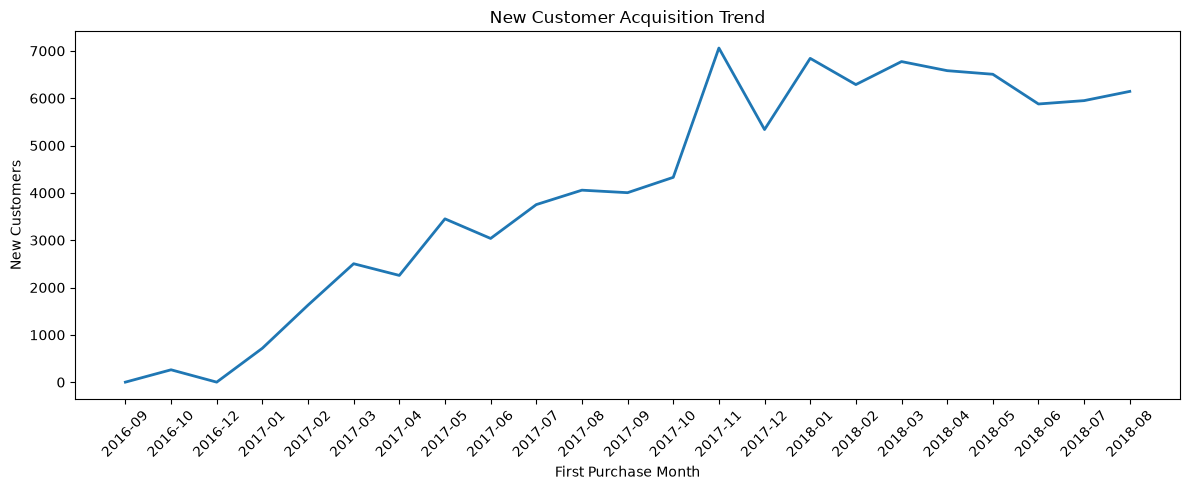

In [37]:
# =========================================================
# NEW CUSTOMER TREND
# =========================================================

plt.figure(figsize=(12, 5))

plt.plot(
    new_customers_monthly[
        "first_purchase_month"
    ].astype(str),
    new_customers_monthly[
        "new_customers"
    ],
    linewidth=2
)

plt.title("New Customer Acquisition Trend")
plt.xlabel("First Purchase Month")
plt.ylabel("New Customers")

plt.xticks(rotation=45)

plt.tight_layout()
plt.show()

## 23. Seller Performance

This section identifies the top sellers based on revenue and order volume.

In [ ]:
# =========================================================
# SELLER PERFORMANCE
# =========================================================

seller_summary = (
    order_items
    .merge(
        orders[
            [
                "order_id",
                "order_status"
            ]
        ],
        on="order_id",
        how="left"
    )
)

seller_summary = seller_summary[
    seller_summary["order_status"] == "delivered"
]

seller_summary = (
    seller_summary
    .groupby("seller_id")
    .agg(
        revenue=("price", "sum"),
        orders=("order_id", "nunique"),
        items_sold=("order_item_id", "count")
    )
    .reset_index()
    .sort_values(
        "revenue",
        ascending=False
    )
)

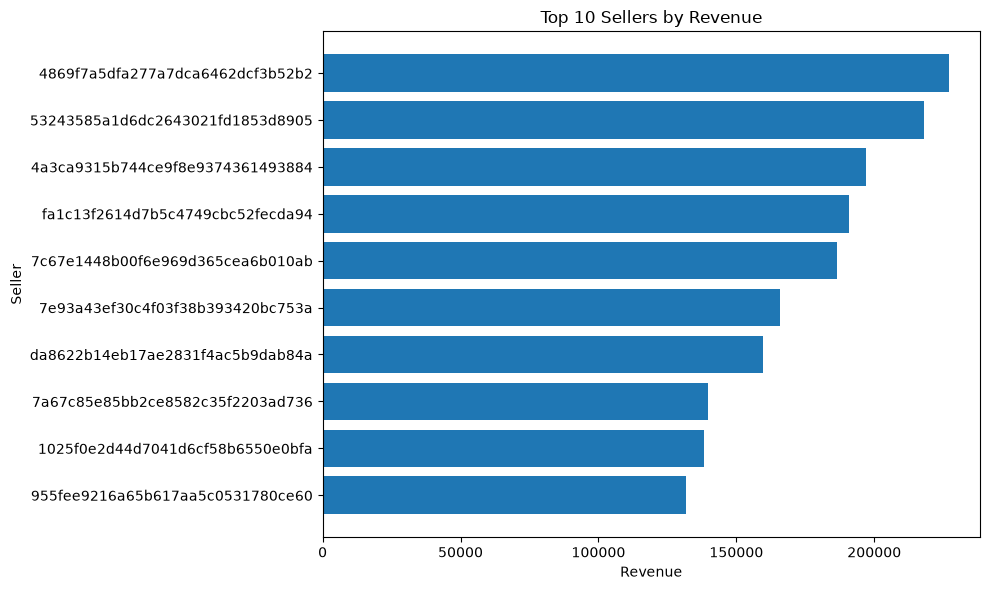

In [ ]:
# =========================================================
# TOP 10 SELLERS BY REVENUE
# =========================================================

top_sellers = seller_summary.head(10)

plt.figure(figsize=(10, 6))

plt.barh(
    top_sellers["seller_id"].astype(str)[::-1],
    top_sellers["revenue"][::-1]
)

plt.title("Top 10 Sellers by Revenue")
plt.xlabel("Revenue")
plt.ylabel("Seller")

plt.tight_layout()
plt.show()

## 25. Delivery Performance

This section analyzes:

- Delivery time
- On-time vs late deliveries
- Delivery performance
- Relationship between delivery and reviews

In [ ]:
# =========================================================
# DELIVERY TIME
# =========================================================

delivered_orders["delivery_days"] = (
    delivered_orders[
        "order_delivered_customer_date"
    ]
    -
    delivered_orders[
        "order_purchase_timestamp"
    ]
).dt.total_seconds() / (24 * 60 * 60)

delivery_summary = (
    delivered_orders["delivery_days"]
    .describe()
)

delivery_summary

count    96470.000000
mean        12.558217
std          9.546156
min          0.533414
25%          6.766204
50%         10.217477
75%         15.720182
max        209.628611
Name: delivery_days, dtype: float64

In [41]:
# =========================================================
# ON-TIME VS LATE DELIVERY
# =========================================================

delivered_orders["delivery_status"] = np.where(
    delivered_orders[
        "order_delivered_customer_date"
    ]
    <=
    delivered_orders[
        "order_estimated_delivery_date"
    ],
    "On Time",
    "Late"
)

delivery_rate = (
    delivered_orders["delivery_status"]
    .value_counts(normalize=True)
    * 100
)

delivery_rate

delivery_status
On Time    91.880014
Late        8.119986
Name: proportion, dtype: float64

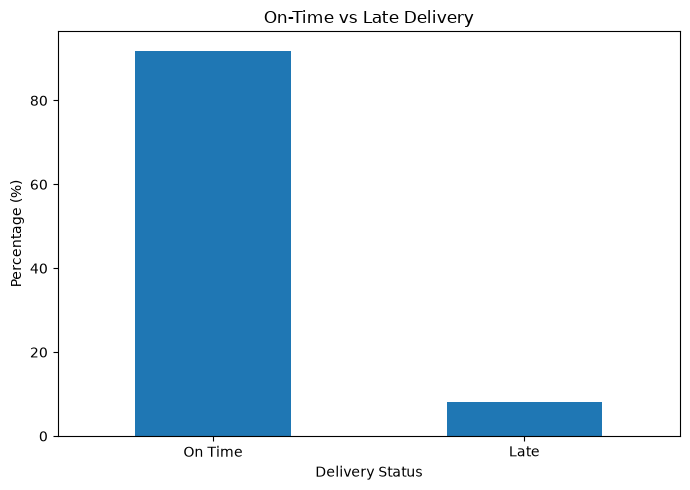

In [42]:
# =========================================================
# DELIVERY PERFORMANCE CHART
# =========================================================

plt.figure(figsize=(7, 5))

delivery_rate.plot(
    kind="bar"
)

plt.title("On-Time vs Late Delivery")
plt.xlabel("Delivery Status")
plt.ylabel("Percentage (%)")

plt.xticks(rotation=0)

plt.tight_layout()
plt.show()

## 28. Payment Analysis

This section examines the preferred payment methods and payment value.

In [43]:
# =========================================================
# PAYMENT METHOD ANALYSIS
# =========================================================

payment_summary = (
    payments
    .groupby("payment_type")
    .agg(
        orders=("order_id", "nunique"),
        payment_value=("payment_value", "sum"),
        average_payment=("payment_value", "mean")
    )
    .reset_index()
    .sort_values(
        "payment_value",
        ascending=False
    )
)

payment_summary

,payment_type,orders,payment_value,average_payment
1,credit_card,76505,12542084.19,163.319021
0,boleto,19784,2869361.27,145.034435
4,voucher,3866,379436.87,65.703354
2,debit_card,1528,217989.79,142.570170
3,not_defined,3,0.00,0.000000


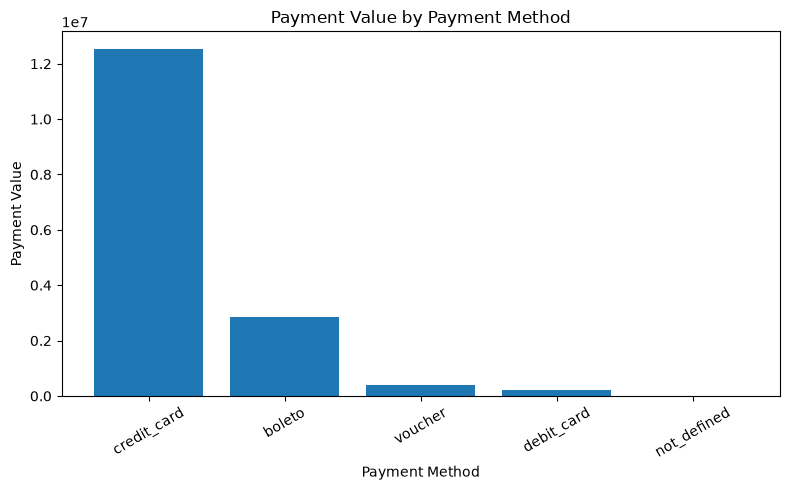

In [44]:
# =========================================================
# PAYMENT METHOD CHART
# =========================================================

plt.figure(figsize=(8, 5))

plt.bar(
    payment_summary["payment_type"],
    payment_summary["payment_value"]
)

plt.title("Payment Value by Payment Method")
plt.xlabel("Payment Method")
plt.ylabel("Payment Value")

plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

## 30. Customer Satisfaction

Review scores are used as the primary indicator of customer satisfaction.

In [ ]:
# =========================================================
# REVIEW SCORE DISTRIBUTION
# =========================================================

review_distribution = (
    reviews["review_score"]
    .value_counts()
    .sort_index()
)

review_distribution

review_score
1    11424
2     3151
3     8179
4    19142
5    57328
Name: count, dtype: int64

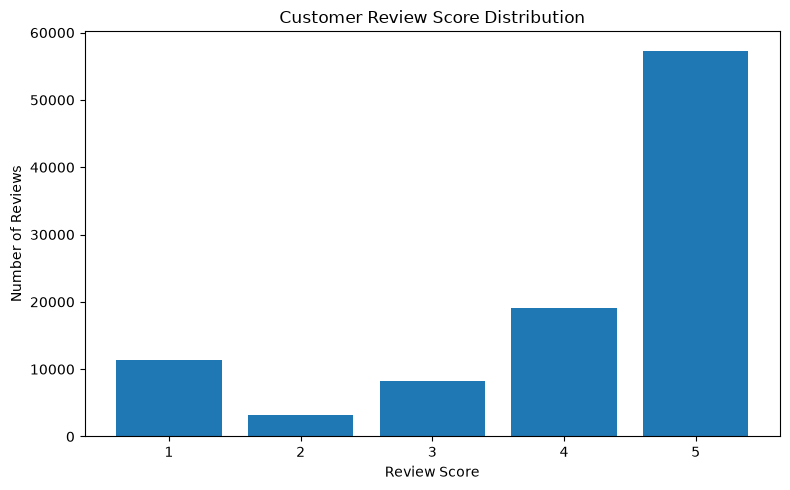

In [46]:
# =========================================================
# REVIEW SCORE CHART
# =========================================================

plt.figure(figsize=(8, 5))

plt.bar(
    review_distribution.index,
    review_distribution.values
)

plt.title("Customer Review Score Distribution")
plt.xlabel("Review Score")
plt.ylabel("Number of Reviews")

plt.tight_layout()
plt.show()

## 32. Delivery Performance vs Customer Satisfaction

This analysis examines whether late delivery is associated with lower
customer review scores.

In [47]:
# =========================================================
# DELIVERY VS REVIEW SCORE
# =========================================================

delivery_reviews = (
    delivered_orders[
        [
            "order_id",
            "delivery_status",
            "delivery_days"
        ]
    ]
    .merge(
        reviews[
            [
                "order_id",
                "review_score"
            ]
        ],
        on="order_id",
        how="inner"
    )
)

delivery_review_summary = (
    delivery_reviews
    .groupby("delivery_status")
    .agg(
        orders=("order_id", "nunique"),
        average_review=("review_score", "mean"),
        average_delivery_days=("delivery_days", "mean")
    )
    .reset_index()
)

delivery_review_summary

,delivery_status,orders,average_review,average_delivery_days
0,Late,7669,2.568500,31.391095
1,On Time,88163,4.293718,10.884060


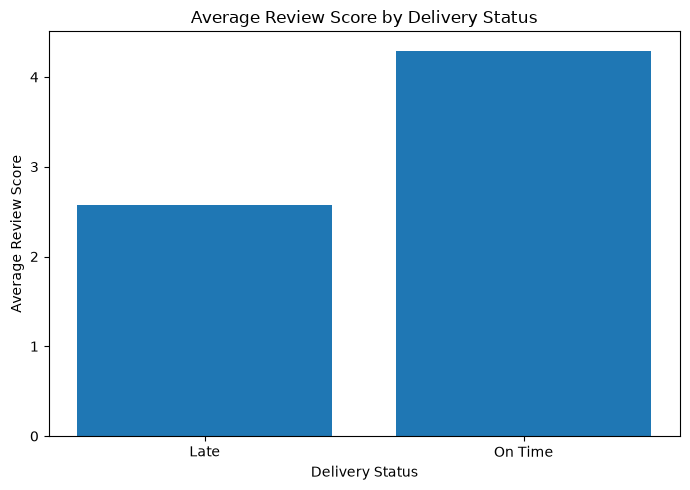

In [48]:
# =========================================================
# DELIVERY VS REVIEW CHART
# =========================================================

plt.figure(figsize=(7, 5))

plt.bar(
    delivery_review_summary["delivery_status"],
    delivery_review_summary["average_review"]
)

plt.title("Average Review Score by Delivery Status")
plt.xlabel("Delivery Status")
plt.ylabel("Average Review Score")

plt.tight_layout()
plt.show()

## 34. Freight Cost Analysis

This section measures freight cost relative to product revenue.

In [49]:
# =========================================================
# 34. FREIGHT ANALYSIS
# =========================================================

freight_analysis = (
    delivered_orders[
        [
            "product_revenue",
            "freight_value"
        ]
    ]
    .sum()
    .to_frame("value")
)

product_revenue = (
    freight_analysis.loc[
        "product_revenue",
        "value"
    ]
)

freight_value = (
    freight_analysis.loc[
        "freight_value",
        "value"
    ]
)

freight_percentage = (
    freight_value
    / product_revenue
    * 100
)

print(f"Product Revenue: {product_revenue:,.2f}")
print(f"Freight Value: {freight_value:,.2f}")
print(
    f"Freight as % of Product Revenue: "
    f"{freight_percentage:.2f}%"
)

Product Revenue: 13,221,498.11
Freight Value: 2,198,275.64
Freight as % of Product Revenue: 16.63%


## 35. Key Business Metrics

A compact summary of the major KPIs identified during EDA.

In [51]:
# =========================================================
# KPI SUMMARY
# =========================================================

total_revenue = delivered_orders[
    "product_revenue"
].sum()

total_orders = delivered_orders[
    "order_id"
].nunique()

total_customers = delivered_orders[
    "customer_unique_id"
].nunique()

average_order_value = (
    total_revenue
    / total_orders
)

average_delivery_days = delivered_orders[
    "delivery_days"
].mean()

late_delivery_rate = (
    delivered_orders["delivery_status"]
    .eq("Late")
    .mean()
    * 100
)

repeat_customer_rate = (
    customer_orders["order_count"]
    .gt(1)
    .mean()
    * 100
)

average_review_score = reviews[
    "review_score"
].mean()

kpi_summary = pd.DataFrame({
    "Metric": [
        "Total Revenue",
        "Total Orders",
        "Total Customers",
        "Average Order Value",
        "Average Delivery Days",
        "Late Delivery Rate",
        "Repeat Customer Rate",
        "Average Review Score"
    ],
    "Value": [
        total_revenue,
        total_orders,
        total_customers,
        average_order_value,
        average_delivery_days,
        late_delivery_rate,
        repeat_customer_rate,
        average_review_score
    ]
})

kpi_summary

,Metric,Value
0,Total Revenue,1.322150e+07
1,Total Orders,9.647800e+04
2,Total Customers,9.335800e+04
3,Average Order Value,1.370416e+02
4,Average Delivery Days,1.255822e+01
5,Late Delivery Rate,8.119986e+00
6,Repeat Customer Rate,3.000278e+00
7,Average Review Score,4.086421e+00


## 36. Key Metric Relationships

A small correlation analysis is used to understand relationships between
revenue, freight costs and delivery time.

In [53]:
# =========================================================
# CORRELATION ANALYSIS
# =========================================================

correlation_data = delivered_orders[
    [
        "product_revenue",
        "freight_value",
        "delivery_days"
    ]
].corr()

correlation_data

,product_revenue,freight_value,delivery_days
product_revenue,1.000000,0.411176,0.055608
freight_value,0.411176,1.000000,0.167171
delivery_days,0.055608,0.167171,1.000000


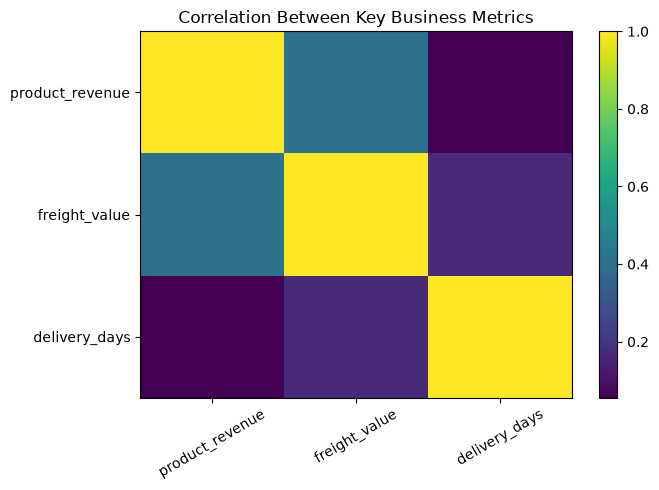

In [54]:
# =========================================================
# CORRELATION HEATMAP
# =========================================================

plt.figure(figsize=(7, 5))

plt.imshow(
    correlation_data,
    aspect="auto"
)

plt.xticks(
    range(len(correlation_data.columns)),
    correlation_data.columns,
    rotation=30
)

plt.yticks(
    range(len(correlation_data.columns)),
    correlation_data.columns
)

plt.title("Correlation Between Key Business Metrics")

plt.colorbar()

plt.tight_layout()
plt.show()

# 38. Business Insights

The following section should contain conclusions based on the actual
results generated above.

### Sales
- Revenue trends and major growth/decline periods should be identified
  from the monthly revenue and MoM growth analysis.
- Average Order Value provides an indication of customer spending per order.

### Customers
- The one-time vs repeat customer analysis indicates the strength of
  customer retention.
- First purchase month analysis shows the customer acquisition trend.

### Products
- The category analysis identifies the highest revenue-generating
  product categories.

### Sellers
- Seller analysis highlights the sellers contributing the most revenue.

### Delivery
- The on-time vs late analysis identifies delivery performance.
- Delivery vs review analysis helps determine whether late deliveries
  are associated with lower customer satisfaction.

### Payments
- Payment analysis identifies the most commonly used and highest-value
  payment methods.

### Freight
- Freight analysis measures the importance of shipping costs relative
  to product revenue.

### Overall Business Opportunity
- The final recommendations should focus on improving customer retention,
  delivery performance, high-performing categories, seller performance
  and operational efficiency.

In [55]:
# =========================================================
# SAVE KEY ANALYTICAL OUTPUTS
# =========================================================

OUTPUT_PATH = Path("../data/processed")

# Create folder if it doesn't exist
OUTPUT_PATH.mkdir(
    parents=True,
    exist_ok=True
)

# Save important analysis tables
monthly_sales.to_csv(
    OUTPUT_PATH / "monthly_sales.csv",
    index=False
)

category_summary.to_csv(
    OUTPUT_PATH / "category_summary.csv",
    index=False
)

customer_orders.to_csv(
    OUTPUT_PATH / "customer_analysis.csv",
    index=False
)

new_customers_monthly.to_csv(
    OUTPUT_PATH / "new_customers_monthly.csv",
    index=False
)

seller_summary.to_csv(
    OUTPUT_PATH / "seller_summary.csv",
    index=False
)

delivery_review_summary.to_csv(
    OUTPUT_PATH / "delivery_review_summary.csv",
    index=False
)

payment_summary.to_csv(
    OUTPUT_PATH / "payment_summary.csv",
    index=False
)

kpi_summary.to_csv(
    OUTPUT_PATH / "kpi_summary.csv",
    index=False
)

print("Key analysis outputs saved successfully.")

Key analysis outputs saved successfully.
